<a href="https://colab.research.google.com/github/YKochura/ml-kpi/blob/main/tutor/principal_component_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Метод головних компонент &mdash; Principal component analysis (PCA)

* [1. Що таке PCA?](#intro-pca)
* [2. Навіщо потрібен PCA?](#why-pca)
* [3. Ключові ідеї PCA](#key-ideas)
* [4. Два способи отримання PCA](#derivation)
    * [4.1 З точки зору максимальної дисперсії](#max-var-perspective)
    * [4.2 З точки зору проєкції](#proj-perspective)

* [5. Інтерпретація матриці проєкції](#interpretation)
* [6. Обчислення власних векторів](#comp-eigenvec)
* [7. Короткий словник ключових термінів](#terminology)
* [8. Реалізація](#implementation)
    * [8.1 Набір даних](#dataset)
    * [8.2 Стандартизація](#standardization)
    * [8.3 Обчислення коваріаційної матриці даних](#comp-cov-matrix)
    * [8.4 Обчислення власних векторів та власних значень](#comp-eig-vecs)
    * [8.5 Вибір кількості власних значень](#num-eig-vals)
    * [8.6 Побудова матриці проєкції](#proj-matrix)
    * [8.7 Проєктування даних](#proj-data)
    * [8.8 Візуалізація перетворених даних](#plot-data)
    * [8.9 Порівняння з scikit-learn](#sklearn-comparison)

## 1. Що таке PCA? <a class="anchor" id="intro-pca"></a>


Метод головних компонент (Principal Component Analysis, PCA) – лiнiйний алгоритм, який використовують для зменшення розмiрностi, вiзуалiзацiї даних, зменшення шуму та видобування нових ознак, якi охоплюють важливу iнформацiю з оригiнального багатовимiрного набору.

Метод винайдений Карлом Пірсоном у 1901 році та згодом розроблений  [Гарольдом Хотеллінгом (Harold Hotelling)](https://en.wikipedia.org/wiki/Harold_Hotelling).

## 2. Навіщо потрібен PCA? <a class="anchor" id="why-pca"></a>

Багато реальних даних є багатовимірними. Уявіть дані пацієнтів у лікарні: для кожного з них може бути сотні або навіть тисячі показників (артеріальний тиск, частота серцевих скорочень, частота дихання тощо). Працювати з такими даними складно — їх дорого зберігати, важко аналізувати й майже неможливо візуалізувати.

На щастя, багато вимірів у багатовимірних даних часто є надлишковими і можуть бути виражені через комбінацію інших вимірів. До того ж, ключова інформація нерідко зосереджена в компактній низьковимірній структурі. Тому багатовимірні дані можна спростити за допомогою методів зменшення розмірності, таких як PCA.

Вiзуалiзацiя даних великої розмiрностi у просторi меншої розмiрностi дозволяє
спростити пошук шаблонiв чи кластерiв у цих даних пiд час навчання моделей машинного навчання. PCA досягає цього шляхом перетворення багатовимiрних даних у нову систему координат, де осi, якi називаються **головними компонентами**, є лiнiйними комбiнацiями ознак багатовимiрного набору даних.

## 3. Ключові ідеї PCA <a class="anchor" id="key-ideas"></a>
- PCA знаходить низьковимірне представлення даних, будуючи нові ознаки (які називають головними компонентами) — лінійні комбінації ознак багатовимiрного набору даних.
- Нові ознаки підбираються не випадково: PCA шукає такі ознаки, які найкраще описують дані з мінімальною втратою інформації.

### Стандартизація
PCA починається з центрування та нормалізації даних. Кожну ознаку $j$ центрують, віднімаючи її середнє значення $\mu_j$, а потім нормалізують, ділячи на стандартне відхилення $\sigma_j$:

$$x_j^{\text{norm}} = \frac{x_j - \mu_j}{\sigma_j}$$

де середнє та стандартне відхилення обчислюються по всьому набору даних:

$$\mu_j = \frac{1}{N}\sum_{n=1}^{N} x_{n,j}, \qquad \sigma_j = \sqrt{\frac{1}{N}\sum_{n=1}^{N}(x_{n,j} - \mu_j)^2},$$

де $x_{n,j}$— це значення $j$-ої ознаки у для $n$-го прикладу.

Після такого перетворення кожна ознака має нульове середнє та одиничне стандартне відхилення, що дозволяє коректно порівнювати ознаки різних масштабів.

## 4. Два способи отримання PCA  <a class="anchor" id="derivation"></a>

Припустимо, що маємо набір даних $\boldsymbol{X}$ у $D$-вимірному просторі та нульовим середнім:
$$\mathcal{\boldsymbol{X}} = \{\boldsymbol{x}_1, ..., \boldsymbol{x}_N\},$$ де $\boldsymbol{x}_n \in \mathbb{R}^D$. Коваріаційна матриця даних (яка знадобиться пізніше) обчислюється так:

$$\boldsymbol{S} = \frac{1}{N} \sum_{n=1}^{N} \boldsymbol{x}_n \boldsymbol{x}_n^T$$

Мета PCA — знайти проєкції точок $\boldsymbol{x}_n$, які якомога менше відрізняються від оригінальних точок у $D$-вимірному просторі, але мають меншу розмірність. До цієї мети можна підійти з двох сторін:

1. **З точки зору максимальної дисперсії:** шукаємо низьковимірне представлення, яке максимізує дисперсію проєктованих даних.
2. **З точки зору проєкції:** шукаємо низьковимірне представлення, яке мінімізує середню похибку реконструкції між оригінальними даними у $D$-вимірному просторі та відновленими даними.

Обидва підходи приводять до одного й того самого результату.


### 4.1 З точки зору максимальної дисперсії <a class="anchor" id="max-var-perspective"></a>

У цьому підході PCA шукає матрицю перетворення $\boldsymbol{B}$, яка проєктує багатовимірні дані $\boldsymbol{X}$ у простір меншої розмірності $M$ із якомога меншою втратою інформації.

> Як гарантувати, що матриця $\boldsymbol{B}$ зберігає максимум інформації? Виявляється, це досягається тоді, коли $\boldsymbol{B}$ проєктує дані так, щоб **максимізувати дисперсію** у новому $M$-вимірному просторі.

Розглянемо матрицю $\boldsymbol{B}$ детальніше. Її можна визначити як набір векторів $\boldsymbol{b}_1, ..., \boldsymbol{b}_M$:

$$\boldsymbol{B} := [\boldsymbol{b}_1, ..., \boldsymbol{b}_M] \in \mathbb{R}^{D \times M}$$

Вектори $\boldsymbol{b}_m$ називають *базисними векторами* — вони утворюють осі нового $M$-вимірного простору.

Можна показати, що максимізація дисперсії еквівалентна вибору тих базисних векторів, які відповідають **найбільшим власним значенням** коваріаційної матриці $\boldsymbol{S}$. Тобто матрицю $\boldsymbol{B}$ будують так: обчислюють власні значення та власні вектори матриці $\boldsymbol{S}$ і обирають $M$ власних векторів із найбільшими власними значеннями.

Точніше: $\boldsymbol{b}_1$ — власний вектор із **найбільшим** власним значенням, він називається *першою головною компонентою*; $\boldsymbol{b}_2$ відповідає другому за величиною власному значенню і є *другою головною компонентою*, і так далі.

Виведення можна знайти у розділі 10.2 книги [Mathematics for Machine Learning](https://mml-book.com).

Маючи матрицю проєкції $\boldsymbol{B}$, кожну точку $\boldsymbol{x}_n$ можна перетворити множенням:

$$\boldsymbol{z}_n = \boldsymbol{B}^T \boldsymbol{x}_n \in \mathbb{R}^M$$

У матричному вигляді це виглядає так:

<img src="https://github.com/YKochura/ml-kpi/blob/main/figures/pca/pca_matrix_multiplications.png?raw=true" width="600"/>

### 4.2 З точки зору проєкції <a class="anchor" id="proj-perspective"></a>

Інший спосіб отримати PCA — розглянути оригінальні дані $\boldsymbol{x}_n$ та їхні відновлення $\boldsymbol{\tilde{x}}_n$. У цьому підході ми шукаємо таку проєкцію, яка мінімізує середню квадратичну евклідову відстань між оригінальними прикладами та їхніми відновленнями:

$$J = \frac{1}{N} \sum_{n=1}^{N}||\boldsymbol{x}_n - \boldsymbol{\tilde{x}}_n ||^2$$

Чим менше значення $J$, тим точніше ми можемо відновити оригінальні дані після стиснення. Обидва підходи: максимізація дисперсії та мінімізація $J$ приводять до одного й того самого результату.

Детальніше про цей підхід — у розділі 10.3 книги [Mathematics for Machine Learning](https://mml-book.com).

## 5. Інтерпретація матриці проєкції <a class="anchor" id="interpretation"></a>

На початку ми згадували, що PCA будує нові ознаки (головні компоненти) як лінійні комбінації оригінального набору. Розглянемо детальніше, що це означає.

Кожна точка зберігається у вигляді вектора з $D$ елементів: $\boldsymbol{x}_n = [x_{n1}, ..., x_{nD}]$, де кожен елемент відповідає окремій ознаці. Наприклад, уявімо зображення з $D = 64$ пікселями. Кожне таке зображення — це вектор із 64 чисел, де кожне число — яскравість одного пікселя:

$$\boldsymbol{x}_n = [x_{n1},\ x_{n2},\ ...,\ x_{n64}]$$

Це те саме, що розкласти зображення на окремі пікселі:

$$\boldsymbol{x}_n = x_{n1} \cdot \boldsymbol{e}_1 + x_{n2} \cdot \boldsymbol{e}_2 + ... + x_{n64} \cdot \boldsymbol{e}_{64}$$

де $\boldsymbol{e}_j$ — одиничний вектор уздовж $j$-ої осі (тобто зображення, де лише $j$-ий піксель увімкнений), а $x_{nj}$ — його яскравість.

Коли PCA проєктує дані у простір меншої розмірності, він також використовує лінійну комбінацію ознак. Це випливає з рівняння проєкції:

$$\boldsymbol{z}_n = \boldsymbol{B}^T \boldsymbol{x}_n \in \mathbb{R}^M$$

Стиснене представлення $\boldsymbol{z}_n$ точки $\boldsymbol{x}_n$ є лінійною комбінацією всіх її ознак. Розглянемо конкретний приклад.

Нехай матриця даних $\boldsymbol{X}$ містить 3 приклади (точки) та 2 ознаки на приклад, тобто $\boldsymbol{X} \in \mathbb{R}^{3 \times 2}$, і ми залишаємо лише першу головну компоненту, тобто $\boldsymbol{B} \in \mathbb{R}^{2 \times 1}$. Тоді добуток $\boldsymbol{X}\boldsymbol{B}$ дає матрицю $\boldsymbol{Z} \in \mathbb{R}^{3 \times 1}$, де кожен одновимірний елемент $\boldsymbol{z}_n$ є лінійною комбінацією вихідних ознак:

<img src="https://github.com/YKochura/ml-kpi/blob/main/figures/pca/linear_combinations.png?raw=true" width="800"/>

## 6. Обчислення власних векторів <a class="anchor" id="comp-eigenvec"></a>

Для PCA нам потрібно обчислити власні значення та власні вектори. Це можна зробити двома способами:

1. **Спектральний розклад** (діагоналізація) коваріаційної матриці $\boldsymbol{S}$:
$$\boldsymbol{S} = \boldsymbol{Q}\boldsymbol{\Lambda}\boldsymbol{Q}^{T}$$

де:
- $\boldsymbol{Q}$ — матриця, стовпці якої є власними векторами $\boldsymbol{q}_1, ..., \boldsymbol{q}_D$
- $\boldsymbol{\Lambda}$ — діагональна матриця, на діагоналі якої стоять відповідні власні значення $\lambda_1 \geq \lambda_2 \geq ... \geq \lambda_D$:

$$\boldsymbol{\Lambda} = \begin{bmatrix}\lambda_1 & 0 & \cdots & 0\\ 0 & \lambda_2 & \cdots & 0\\ \vdots & \vdots & \ddots & \vdots\\ 0 & 0 & \cdots & \lambda_D\end{bmatrix}$$

Інтуїція: власні вектори $\boldsymbol{q}_j$ вказують **напрямки** розкиду даних, а власні значення $\lambda_j$ показують **наскільки великий** розкид у кожному напрямку. PCA обирає $M$ напрямків із найбільшими $\lambda_j$ — тобто ті, вздовж яких дані «розтягнуті» найсильніше.

2. **Сингулярний розклад** матриці даних $\boldsymbol{X}$

**Сингулярний розклад (SVD)** розкладає довільну матрицю $\boldsymbol{X} \in \mathbb{R}^{N \times D}$ у вигляді:

$$\boldsymbol{X} = \boldsymbol{U}\boldsymbol{\Sigma}\boldsymbol{V}^T$$

де:
- $\boldsymbol{U} \in \mathbb{R}^{N \times N}$ — матриця лівих сингулярних векторів
- $\boldsymbol{\Sigma} \in \mathbb{R}^{N \times D}$ — діагональна матриця сингулярних чисел
- $\boldsymbol{V} \in \mathbb{R}^{D \times D}$ — матриця правих сингулярних векторів

Зв'язок із PCA: можна показати, що **праві сингулярні вектори** $\boldsymbol{V}$ збігаються з власними векторами коваріаційної матриці $\boldsymbol{S}$. Тому SVD матриці $\boldsymbol{X}$ дає той самий результат, що й спектральний розклад $\boldsymbol{S}$ — просто іншим шляхом.

У цьому документі будемо використовувати перший спосіб. Детальніше про другий — у розділі 10.4 книги [Mathematics for Machine Learning](https://mml-book.com).

**Зауваження:** на практиці часто потрібні лише перші кілька власних векторів. Повний спектральний або сингулярний розклад у такому випадку був б надлишково дорогим з обчислювальної точки зору. Тому більшість бібліотек реалізують ітеративні методи, які одразу знаходять лише потрібну кількість власних векторів.

## 7. Короткий словник ключових термінів <a class="anchor" id="terminology"></a>

- $\boldsymbol{x}_n$ — екземпляри даних (приклади), зібрані у матрицю $\mathcal{\boldsymbol{X}} = \{\boldsymbol{x}_1, ..., \boldsymbol{x}_N\}$, де $\boldsymbol{x}_n \in \mathbb{R}^D$
- $\boldsymbol{S}$ — коваріаційна матриця даних
- $\boldsymbol{B}$ — матриця проєкції, стовпці якої є базисними векторами $\boldsymbol{b}_m$: $\boldsymbol{B} := [\boldsymbol{b}_1, ..., \boldsymbol{b}_M] \in \mathbb{R}^{D \times M}$
- $\boldsymbol{z}_n$ — стиснене (низьковимірне) представлення $\boldsymbol{x}_n$: $\boldsymbol{z}_n = \boldsymbol{B}^T \boldsymbol{x}_n \in \mathbb{R}^M$

## 8. Реалізація <a class="anchor" id="implementation"></a>

In [1]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

### 8.1 Набір даних <a class="anchor" id="dataset"></a>

Для реалізації використаємо набір даних `digits` із бібліотеки `scikit-learn`. Він містить 1797 зображень рукописних цифр розміром $8 \times 8$ пікселів. Дані зберігаються у матриці розміром $1797 \times 64$, де кожен рядок — одне зображення, а кожен стовпець — значення одного з $8 \times 8 = 64$ пікселів.

Розмір матриці даних: (1797, 64)
Розмір вектора міток: (1797,)


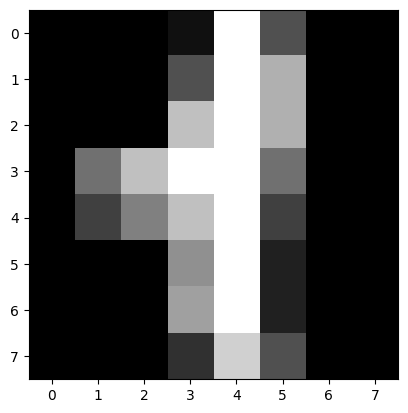

In [9]:
digits = load_digits()
data, labels = digits.data, digits.target

print(f"Розмір матриці даних: {data.shape}")
print(f"Розмір вектора міток: {labels.shape}")

# Приклад зображення
plt.imshow(digits.images[85], cmap="gray");

### 8.2 Стандартизація <a class="anchor" id="standardization"></a>

Перед застосуванням PCA дані необхідно стандартизувати — перетворити так, щоб кожна ознака мала нульове середнє та одиничне стандартне відхилення. Це дозволяє коректно порівнювати ознаки різних масштабів.

In [10]:
mean = np.mean(data, axis=0)
std = np.std(data, axis=0)
# Якщо стандартне відхилення ознаки дорівнює нулю, ділення на нього
# призведе до помилки. Тому замінюємо такі значення на одиницю.
std[std == 0] = 1.
data_norm = (data - mean) / std

# Те саме можна зробити за допомогою scikit-learn
from sklearn.preprocessing import StandardScaler
data_norm_sklearn = StandardScaler().fit_transform(data)

### 8.3 Обчислення коваріаційної матриці даних <a class="anchor" id="comp-cov-matrix"></a>

Для знаходження головних компонент спочатку обчислимо коваріаційну матрицю $\boldsymbol{S}$:

$$\boldsymbol{S} = \frac{1}{N} \sum_{n=1}^{N} \boldsymbol{x}_n \boldsymbol{x}_n^T$$

Суму можна записати у матричному вигляді:

$$\boldsymbol{S} = \frac{1}{N} \boldsymbol{X}^T \boldsymbol{X}$$

In [11]:
n_samples, n_features = data_norm.shape
cov_matrix = (data_norm.T.dot(data_norm)) / n_samples

# Те саме можна обчислити за допомогою numpy (див. нижче).
# Зауваження: numpy ділить на n_samples - 1, а не на n_samples.
# Це називається поправкою Бесселя — детальніше у відповідній
# статті на Wikipedia.
cov_matrix_numpy = np.cov(data_norm.T)

### 8.4 Обчислення власних векторів та власних значень <a class="anchor" id="comp-eig-vecs"></a>

Для знаходження власних значень та власних векторів виконаємо спектральний розклад коваріаційної матриці $\boldsymbol{S}$. Робити це вручну складно і громіздко, тому скористаємось numpy. Детальніше про алгоритми спектрального розкладу — у [статті на Wikipedia](https://en.wikipedia.org/wiki/Eigendecomposition_of_a_matrix#Numerical_computations).

In [12]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print(f"Розмір вектора власних значень: {eig_vals.shape}")
print(f"Розмір матриці власних векторів: {eig_vecs.shape}")
print("=====================================")

# Шукаємо власні вектори з найбільшими власними значеннями.
# np.argsort повертає індекси, які відсортували б масив за зростанням.
# Оскільки нам потрібне сортування за спаданням, обертаємо результат.
sorted_indices = np.argsort(eig_vals)[::-1]

# Перевіряємо перші кілька власних значень — переконуємось, що відсортовано правильно
for idx in sorted_indices[:3]:
    print(f"Власне значення: {eig_vals[idx]}")

Розмір вектора власних значень: (64,)
Розмір матриці власних векторів: (64, 64)
Власне значення: 7.340688819618319
Власне значення: 5.832243185889717
Власне значення: 5.151093084500992


### 8.5 Вибір кількості власних значень <a class="anchor" id="num-eig-vals"></a>

Кількість власних значень, які ми обираємо, визначає розмірність нового простору. Тому перед вибором варто запитати себе: яка мета?

Зазвичай PCA використовують для зниження розмірності, але при цьому хочуть втратити якомога менше інформації. Тому слід обирати ті власні значення, які пояснюють **найбільшу частку дисперсії** даних.

Як правило, перші кілька власних значень захоплюють більшу частину дисперсії, тоді як решта додають мало інформації. У бібліотеках на кшталт scikit-learn можна одразу вказати, яку частку дисперсії має пояснювати розв'язок — і кількість компонент підбереться автоматично.

У нашому випадку визначимо потрібну кількість головних компонент, обчисливши **частку поясненої дисперсію** кожного власного вектора.


**Частка поясненої дисперсії** $r_j$ — це відношення власного значення $\lambda_j$ до суми всіх власних значень:

$$r_j = \frac{\lambda_j}{\sum_{d=1}^{D} \lambda_d}$$

Вона показує, яку частку загального розкиду даних пояснює $j$-та головна компонента. Наприклад, $r_1 = 0.4$ означає, що перша компонента пояснює 40% дисперсії.

Щоб оцінити, скільки компонент достатньо, зазвичай дивляться на **накопичену пояснену дисперсію**:

$$R_M = \sum_{j=1}^{M} r_j$$

і обирають таке $M$, при якому $R_M \geq 0.95$ (тобто зберігається 95% інформації).

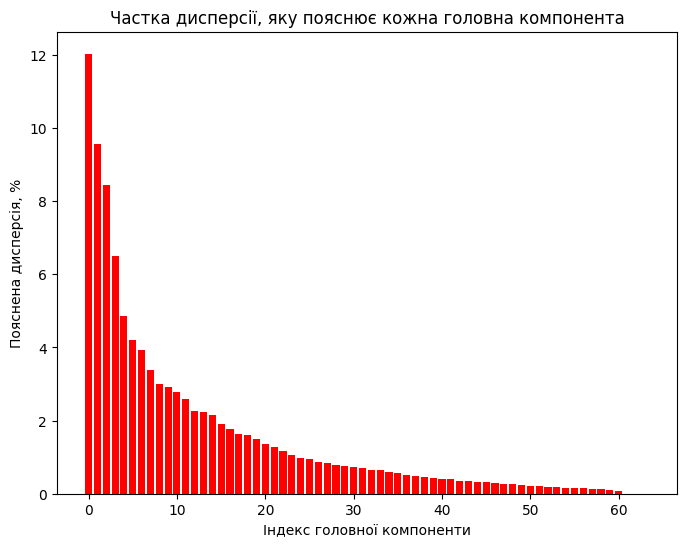

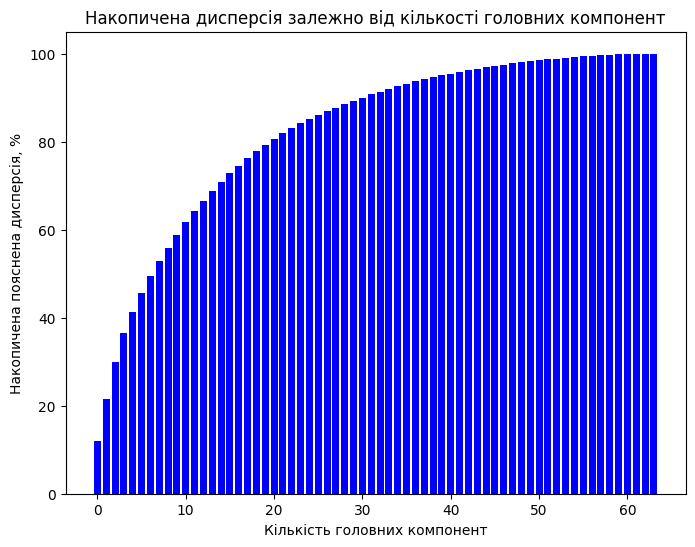

In [13]:
sum_eig_vals = sum(eig_vals)
sorted_eig_vals = sorted(eig_vals, reverse=True)
explained_variance = [(eig_val / sum_eig_vals) * 100 for eig_val in sorted_eig_vals]
cumulative_explained_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 6))
plt.bar(range(len(eig_vals)), explained_variance, label="Пояснена дисперсія", color="red")
plt.xlabel("Індекс головної компоненти")
plt.ylabel("Пояснена дисперсія, %")
plt.title("Частка дисперсії, яку пояснює кожна головна компонента")
plt.show()

plt.figure(figsize=(8, 6))
plt.bar(range(len(eig_vals)), cumulative_explained_variance, label="Накопичена пояснена дисперсія", color="blue")
plt.xlabel("Кількість головних компонент")
plt.ylabel("Накопичена пояснена дисперсія, %")
plt.title("Накопичена дисперсія залежно від кількості головних компонент")
plt.show()

Верхній графік показує, що перші головні компоненти пояснюють більшу частку дисперсії, ніж наступні. Проте жодна окрема компонента не пояснює її дуже багато. Це означає, що при використанні лише кількох перших компонент ми втратимо значну частину інформації. Нижній графік показує, що для збереження 90% дисперсії потрібно залишити 31 головну компоненту — це багато, але все одно краще, ніж зберігати всі 64 ознаки.

Для прикладу залишимо лише 2 найбільші власні значення та відповідні їм власні вектори — це дозволить візуалізувати результат у двовимірному просторі.

In [14]:
# Обираємо лише потрібну кількість власних значень / головних компонент
n_principal_comps = 2
eig_vals = eig_vals[sorted_indices[:n_principal_comps]]
eig_vecs = eig_vecs[:, sorted_indices[:n_principal_comps]]

print(f"Розмір вектора власних значень: {eig_vals.shape}")
print(f"Розмір матриці власних векторів: {eig_vecs.shape}")

Розмір вектора власних значень: (2,)
Розмір матриці власних векторів: (64, 2)


### 8.6 Побудова матриці проєкції <a class="anchor" id="proj-matrix"></a>

Знайшовши власні вектори (головні компоненти), складемо з них матрицю проєкції $\boldsymbol{B}$, стовпці якої — це відібрані власні вектори.

In [15]:
vector_list = [vec.reshape(n_features, 1) for vec in eig_vecs.T]
proj_matrix = np.hstack(vector_list)  # Це і є наша матриця проєкції B
print(f"Розмір матриці проєкції: {proj_matrix.shape}")

Розмір матриці проєкції: (64, 2)


### 8.7 Проєктування даних <a class="anchor" id="proj-data"></a>

Щоб перенести оригінальні багатовимірні дані $\boldsymbol{X}$ у простір меншої розмірності, помножимо матрицю даних на матрицю проєкції $\boldsymbol{B}$:

$$\boldsymbol{Z} = \boldsymbol{X} \boldsymbol{B} \in \mathbb{R}^{N \times M}$$

<img src="https://github.com/YKochura/ml-kpi/blob/main/figures/pca/pca_digits_matrix_multiplications.png?raw=true" width="600"/>

In [16]:
data_proj = data_norm.dot(proj_matrix)  # Це і є наша стиснена матриця даних Z
print(f"Розмір матриці проєктованих даних: {data_proj.shape}")

Розмір матриці проєктованих даних: (1797, 2)


### 8.8 Візуалізація перетворених даних <a class="anchor" id="plot-data"></a>

Оскільки ми залишили лише дві головні компоненти, результат легко візуалізувати на площині: одна вісь відповідає першій головній компоненті, інша — другій.

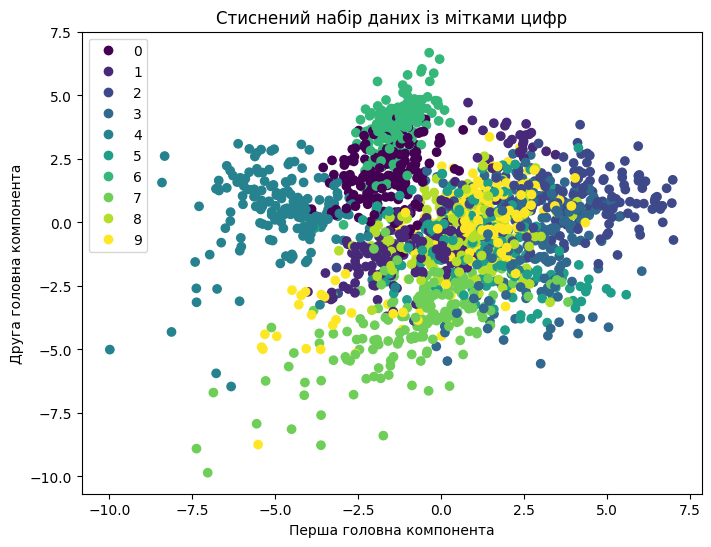

In [17]:
labels_str = ["0", "1", "2", "3", "4", "5", "6", "7", "8", "9"]

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data_proj[:, 0], data_proj[:, 1], c=labels)
plt.legend(handles=scatter.legend_elements()[0], labels=labels_str, loc="upper left")
plt.xlabel('Перша головна компонента')
plt.ylabel('Друга головна компонента')
plt.title("Стиснений набір даних із мітками цифр")
plt.show();

### 8.9 Порівняння з scikit-learn <a class="anchor" id="sklearn-comparison"></a>

Ручна реалізація PCA — це чудовий спосіб зрозуміти, що відбувається «під капотом». Проте на практиці немає сенсу писати все з нуля, оскільки можна скористатись готовими бібліотеками, наприклад scikit-learn, які роблять те саме надійніше та швидше. Застосуємо PCA зі scikit-learn до нашого набору даних і порівняємо результати.

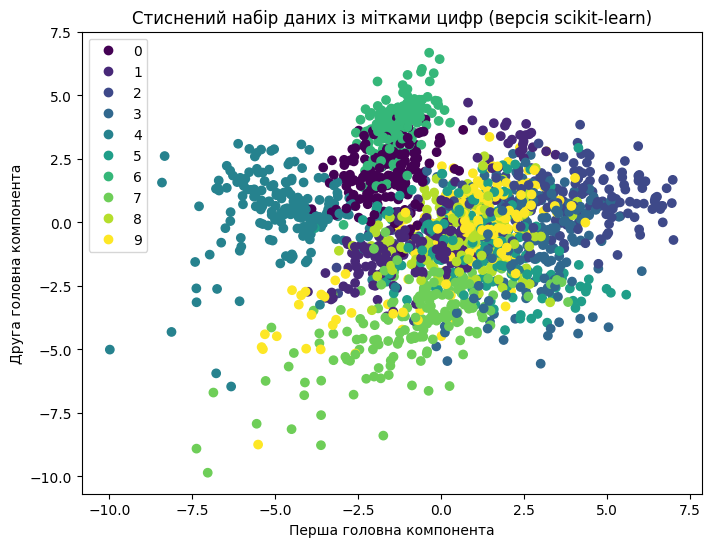

In [22]:
from sklearn.decomposition import PCA
sklearn_pca = PCA(n_components=2)
data_proj_sklearn = sklearn_pca.fit_transform(data_norm)
# Друга головна компонента у scikit-learn спрямована у протилежний бік —
# відзеркалюємо по осі X, щоб графіки збіглись.
data_proj_sklearn[:, 1] *= -1

plt.figure(figsize=(8, 6))
scatter = plt.scatter(data_proj_sklearn[:, 0], data_proj_sklearn[:, 1], c=labels, label=labels_str)
plt.xlabel('Перша головна компонента')
plt.ylabel('Друга головна компонента')
plt.legend(handles=scatter.legend_elements()[0], labels=labels_str, loc="upper left")
plt.title("Стиснений набір даних із мітками цифр (версія scikit-learn)")
plt.show()

 Як видно з графіка, наша реалізація дає той самий результат, що й версія scikit-learn!